In [1]:
%pip install pandas numpy scipy plotly
%pip install --upgrade jsonschema isoduration fastjsonschema
%pip install --upgrade nbformat ipykernel
%pip install seaborn matplotlib
%pip install scikit-learn xgboost lightgbm
%pip install shap
%pip install ipywidgets tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.9-py3-none-any.whl (140 kB)
Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl (217 kB)
Using cached widgetsnbextension-4.0.16-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import iqr
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

In [3]:
# Load the dataset
file_path = "data/processed/medicare_acs_analysis.csv"
analysis_df = pd.read_csv(file_path)

# Data validation function
def validate_data(analysis_df):
    validation_results = {}

    # 1. Check for missing values
    missing_values = analysis_df.isnull().sum()
    validation_results['missing_values'] = missing_values[missing_values > 0].to_dict()

    # 2. Confirm data types
    expected_dtypes = {
        'county': 'object',
        'state': 'object',
        'inpatient_rate': 'float64',
        'outpatient_rate': 'float64',
        'ed_rate': 'float64',
        'socioeconomic_factor_1': 'float64',  # Replace with actual column names
        'socioeconomic_factor_2': 'float64'  # Replace with actual column names
    }
    dtype_issues = {}
    for col, expected_dtype in expected_dtypes.items():
        if col in analysis_df.columns and analysis_df[col].dtype != expected_dtype:
            dtype_issues[col] = {'expected': expected_dtype, 'actual': str(analysis_df[col].dtype)}
    validation_results['dtype_issues'] = dtype_issues

    # 3. Ensure utilization rates are scaled per 1,000 beneficiaries
    utilization_columns = ['inpatient_rate', 'outpatient_rate', 'ed_rate']
    utilization_issues = {}
    for col in utilization_columns:
        if col in analysis_df.columns:
            if not ((analysis_df[col] >= 0) & (analysis_df[col] <= 1000)).all():
                utilization_issues[col] = {
                    'min': analysis_df[col].min(),
                    'max': analysis_df[col].max()
                }
    validation_results['utilization_issues'] = utilization_issues

    return validation_results

# Run validation
validation_results = validate_data(analysis_df)

# Print validation results
print("Validation Results:")
for key, value in validation_results.items():
    print(f"{key}: {value}")

Validation Results:
missing_values: {'avg_annual_om_beneficiaries': 1, 'avg_age': 1, 'female_pct': 3, 'male_pct': 3, 'inpatient_stays_per_1000': 4, 'outpatient_visits_per_1000': 2, 'er_visits_per_1000': 3, 'median_household_income': 1}
dtype_issues: {}
utilization_issues: {}


In [4]:
# Drop rows with missing values
analysis_df = analysis_df.dropna()

## Descriptive Analysis

To analyze how inpatient, outpatient, and emergency department utilization rates vary geographically, we computed summary statistics (i.e., mean, median, interquartile range, standard deviation) and generate county-level choropleth maps across all three care settings. Through this, we expected to learn the baseline distribution, dispersion, and spatial clustering of healthcare utilization per 1,000 beneficiaries across U.S. counties.

In [5]:
utilization_columns = ['inpatient_stays_per_1000', 'outpatient_visits_per_1000', 'er_visits_per_1000']

descriptive_stats = {}

for col in utilization_columns:
    descriptive_stats[col] = {
        'mean': analysis_df[col].mean(),
        'median': analysis_df[col].median(),
        'iqr': iqr(analysis_df[col]),
        'std_dev': analysis_df[col].std()
    }

# Print descriptive statistics
print("Descriptive Statistics:")
for col, stats in descriptive_stats.items():
    print(f"{col}: {stats}")

# Generate county-level choropleth maps
# Ensure the DataFrame has a 'fips' column for county-level mapping
if 'fips' not in analysis_df.columns:
    raise ValueError("The dataset must contain a 'fips' column with valid U.S. county FIPS codes.")

# Create choropleth maps for each care setting
for col in utilization_columns:
    fig = px.choropleth(
        analysis_df,
        geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
        locations='fips',
        color=col,
        color_continuous_scale="Viridis",
        scope="usa",
        title=f"County-Level Choropleth Map: {col.replace('_', ' ').title()}",
        labels={col: f"{col.replace('_', ' ').title()} (per 1,000 beneficiaries)"}
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.show()

Descriptive Statistics:
inpatient_stays_per_1000: {'mean': np.float64(215.47971246132215), 'median': np.float64(215.25837351212343), 'iqr': np.float64(53.71852294597255), 'std_dev': np.float64(41.10591996171189)}
outpatient_visits_per_1000: {'mean': np.float64(5451.299406859644), 'median': np.float64(5122.8161585136895), 'iqr': np.float64(3133.910331311811), 'std_dev': np.float64(2206.735537406361)}
er_visits_per_1000: {'mean': np.float64(588.5121662634278), 'median': np.float64(589.2006744875562), 'iqr': np.float64(134.80066182709982), 'std_dev': np.float64(107.84880897944801)}


## Correlation Analysis

We calculated Pearson and Spearman rank correlation coefficients to quantify the linear and monotonic relationships between county-level socioeconomic factors (e.g., median household income, poverty rate, educational attainment) and healthcare utilization rates.

Pearson correlations quantify linear associations, while Spearman correlations assess monotonic associations that are less sensitive to skew and outliers. Each coefficient uses pairwise-complete observations for the relevant socioeconomic and utilization variables.

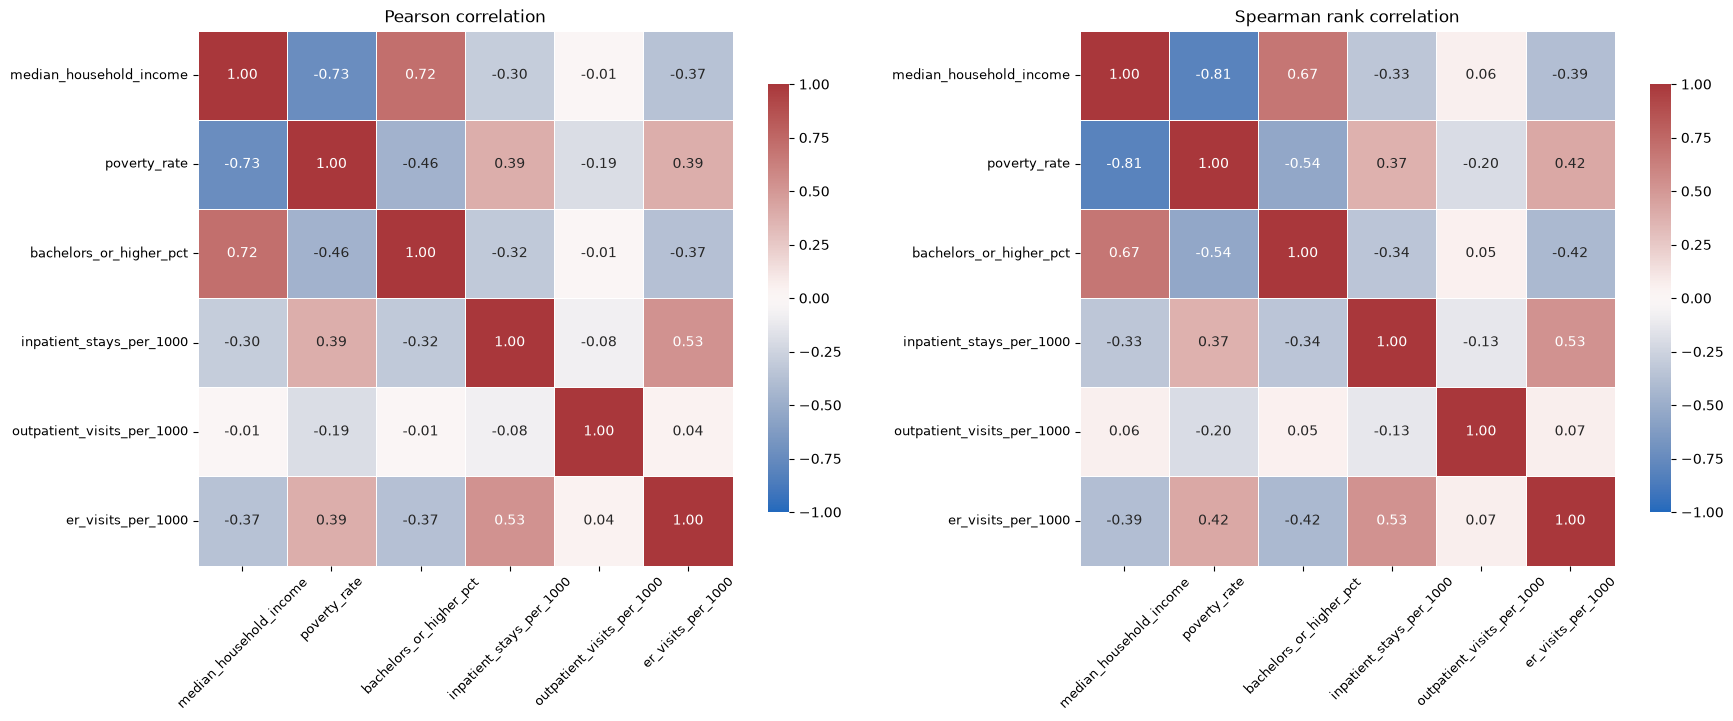

Pearson correlation matrix:
                            median_household_income  poverty_rate  bachelors_or_higher_pct  inpatient_stays_per_1000  outpatient_visits_per_1000  er_visits_per_1000
median_household_income                       1.000        -0.727                    0.718                    -0.295                      -0.012              -0.366
poverty_rate                                 -0.727         1.000                   -0.465                     0.386                      -0.191               0.386
bachelors_or_higher_pct                       0.718        -0.465                    1.000                    -0.316                      -0.006              -0.369
inpatient_stays_per_1000                     -0.295         0.386                   -0.316                     1.000                      -0.080               0.525
outpatient_visits_per_1000                   -0.012        -0.191                   -0.006                    -0.080                       1.000   

In [6]:
feature_names = ["median_household_income", "poverty_rate", "bachelors_or_higher_pct"]
target_names = ["inpatient_stays_per_1000", "outpatient_visits_per_1000", "er_visits_per_1000"]
analysis_columns = feature_names + target_names
correlation_data = analysis_df[analysis_columns]

pearson_corr = correlation_data.corr(method="pearson")
spearman_corr = correlation_data.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, matrix, title in zip(
    axes,
    (pearson_corr, spearman_corr),
    ("Pearson correlation", "Spearman rank correlation"),
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
fig.tight_layout()
plt.show()

print("Pearson correlation matrix:")
print(pearson_corr.round(3).to_string())
print("\nSpearman rank correlation matrix:")
print(spearman_corr.round(3).to_string())

## Predictive Analysis via Supervised Learning

We trained tree-based ensemble models (i.e., Random Forest, XGBoost, LightGBM) evaluated against baseline regularized linear models (i.e., Ridge and Lasso Regression) using 5-fold cross-validation evaluated via R-squared and Root Mean Squared Error (RMSE). Through this, we expected to learn how accurately a county's socioeconomic profile can predict its healthcare utilization rates on out-of-sample data and determine whether non-linear models outperform linear baselines.

We predict each utilization outcome separately from the three socioeconomic indicators. To make out-of-sample evaluation more geographically demanding, counties from a state are kept together: a 20% state-group holdout is reserved for final testing, and five-fold `GroupKFold` cross-validation is conducted only within the training states. Linear models are standardized in pipelines; tree-based models use fixed, regularized settings. The reported comparison includes mean and standard deviation across CV folds and the untouched holdout R²/RMSE.

In [7]:
# Use only the variables needed for each analysis; retain rows with unrelated missing fields.
model_data = analysis_df.dropna(subset=analysis_columns + ["fips", "county_name"]).copy()
model_data["state_fips"] = model_data["fips"].astype(str).str.zfill(5).str[:2]
X = model_data[feature_names]
state_groups = model_data["state_fips"]

train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42).split(X, groups=state_groups)
)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
train_groups = state_groups.iloc[train_idx]
test_groups = state_groups.iloc[test_idx]
cv = GroupKFold(n_splits=5)


def make_models():
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, max_features=1.0,
            random_state=42, n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror", n_estimators=300, learning_rate=0.04,
            max_depth=3, min_child_weight=5, subsample=0.8,
            colsample_bytree=0.9, reg_lambda=2.0, random_state=42,
            n_jobs=-1, verbosity=0,
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=300, learning_rate=0.04, num_leaves=15,
            max_depth=-1, min_child_samples=20, reg_lambda=2.0,
            random_state=42, n_jobs=-1, verbosity=-1,
        ),
    }


comparison_rows = []
fitted_models = {}
holdout_predictions = {}
for target in target_names:
    y = model_data[target]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    for model_name, estimator in make_models().items():
        cv_result = cross_validate(
            estimator,
            X_train,
            y_train,
            cv=cv,
            groups=train_groups,
            scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
            n_jobs=1,
            return_train_score=True,
        )
        estimator.fit(X_train, y_train)
        prediction = estimator.predict(X_test)
        comparison_rows.append({
            "Outcome": target,
            "Model": model_name,
            "CV R2 mean": cv_result["test_r2"].mean(),
            "CV R2 SD": cv_result["test_r2"].std(ddof=1),
            "CV Train R2": cv_result["train_r2"].mean(),
            "CV Train RMSE": -cv_result["train_rmse"].mean(),
            "CV RMSE mean": -cv_result["test_rmse"].mean(),
            "CV RMSE SD": cv_result["test_rmse"].std(ddof=1),
            "Holdout R2": estimator.score(X_test, y_test),
            "Holdout RMSE": np.sqrt(np.mean((y_test.to_numpy() - prediction) ** 2)),
        })
        fitted_models[(target, model_name)] = estimator
        holdout_predictions[target] = y_test, prediction

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    ["Outcome", "CV RMSE mean"]
).reset_index(drop=True)
print(f"Complete-case observations: {len(model_data):,}; training counties: {len(train_idx):,}; holdout counties: {len(test_idx):,}")
print(f"Training states: {train_groups.nunique()}; held-out states: {test_groups.nunique()}")
print(model_comparison.round(3).to_string(index=False))

# Select the lowest-CV-RMSE tree ensemble independently for each utilization outcome.
tree_names = ["Random Forest", "XGBoost", "LightGBM"]
best_tree_by_target = {}
for target in target_names:
    target_scores = model_comparison[
        (model_comparison["Outcome"] == target)
        & model_comparison["Model"].isin(tree_names)
    ].sort_values("CV RMSE mean")
    winner = target_scores.iloc[0]["Model"]
    best_tree_by_target[target] = fitted_models[(target, winner)]
    print(f"Best tree model for {target}: {winner} (CV RMSE={target_scores.iloc[0]['CV RMSE mean']:.2f})")

Complete-case observations: 3,129; training counties: 2,536; holdout counties: 593
Training states: 39; held-out states: 10
                   Outcome         Model  CV R2 mean  CV R2 SD  CV Train R2  CV Train RMSE  CV RMSE mean  CV RMSE SD  Holdout R2  Holdout RMSE
        er_visits_per_1000         Lasso       0.115     0.142        0.196         97.250        99.015      14.906       0.152        93.985
        er_visits_per_1000         Ridge       0.114     0.142        0.196         97.250        99.032      14.914       0.152        93.989
        er_visits_per_1000       XGBoost       0.079     0.148        0.363         86.571       100.923      14.585       0.193        91.703
        er_visits_per_1000      LightGBM       0.051     0.142        0.446         80.710       102.391      13.911       0.158        93.674
        er_visits_per_1000 Random Forest       0.030     0.145        0.767         52.371       103.585      14.545       0.152        94.009
  inpatient_stays_

## Feature Importance Analysis and Residual Analysis

We applied SHAP (SHapley Additive exPlanations) values to our top-performing models to interpret feature attribution. Through this, we expected to learn which socioeconomic drivers hold the strongest predictive power and uncover potential non-linear threshold effects (e.g., whether ED reliance spikes once poverty crosses a specific tipping point).

We computed model prediction residuals (i.e., the differences between actual and predicted values) on holdout test data to identify outlier counties. Through this, we expected to learn which U.S. regions exhibit healthcare utilization that is unexpectedly high or low relative to what local socioeconomic conditions predict.

For each outcome, the ensemble with the lowest mean five-fold CV RMSE is interpreted using `shap.Explainer`. SHAP summary plots display both feature importance and the direction/distribution of attribution on held-out counties. Residuals are defined as observed minus predicted utilization; the ten largest absolute residuals are reported for each outcome.

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Mean absolute SHAP attribution: inpatient_stays_per_1000
bachelors_or_higher_pct    10.836
poverty_rate                6.556
median_household_income     3.516


/var/folders/qf/2jxs0p9141n32pfwvs83n0jh0000gn/T/ipykernel_31414/1160330592.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


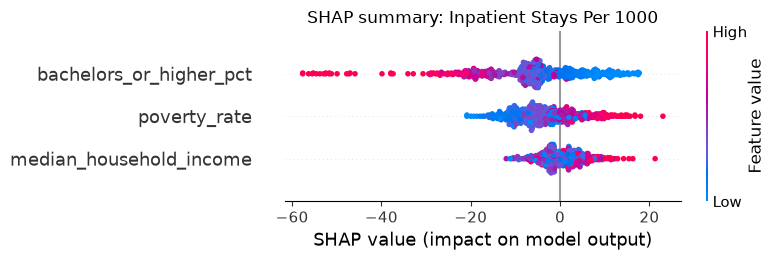

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Top 10 holdout residual outliers: inpatient_stays_per_1000
 fips     county_name  actual  predicted  residual  absolute_residual
53019        WA-Ferry  115.61     224.20   -108.59             108.59
55037     WI-Florence  150.42     256.36   -105.94             105.94
31117    NE-McPherson  303.51     199.95    103.56             103.56
51520 VA-Bristol City  303.90     201.18    102.72             102.72
53001        WA-Adams  144.59     246.67   -102.08             102.08
53051 WA-Pend Oreille  119.84     220.49   -100.65             100.65
53037     WA-Kittitas  123.99     222.96    -98.96              98.96
25021      MA-Norfolk  271.23     174.60     96.63              96.63
53047     WA-Okanogan  131.68     225.45    -93.77              93.77
25009        MA-Essex  264.01     174.47     89.54              89.54

Mean absolute SHAP attribution: outpatient_visits_per_1000
poverty_rate               539.680
median_household_income    515.613
bachelors_or_higher_pct    241.499


/var/folders/qf/2jxs0p9141n32pfwvs83n0jh0000gn/T/ipykernel_31414/1160330592.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


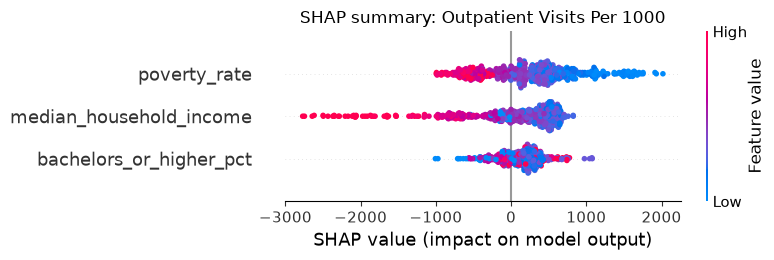

Background dataset has 2536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2536 when initializing the masker.



Top 10 holdout residual outliers: outpatient_visits_per_1000
 fips    county_name   actual  predicted  residual  absolute_residual
55063   WI-La Crosse 12716.75    5067.25   7649.50            7649.50
19167       IA-Sioux 13097.20    5551.96   7545.24            7545.24
19069    IA-Franklin 12697.81    6015.86   6681.95            6681.95
19081     IA-Hancock 12487.03    6480.41   6006.62            6006.62
19145        IA-Page 11896.94    6219.35   5677.58            5677.58
31057       NE-Dundy 11841.80    6174.36   5667.44            5667.44
25007       MA-Dukes  9610.64    4094.26   5516.39            5516.39
55045       WI-Green 10394.00    5126.44   5267.56            5267.56
55121 WI-Trempealeau 10618.22    5353.27   5264.95            5264.95
19143     IA-Osceola  9560.47    4426.25   5134.22            5134.22

Mean absolute SHAP attribution: er_visits_per_1000
bachelors_or_higher_pct    21.946
median_household_income    18.900
poverty_rate               17.196


/var/folders/qf/2jxs0p9141n32pfwvs83n0jh0000gn/T/ipykernel_31414/1160330592.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


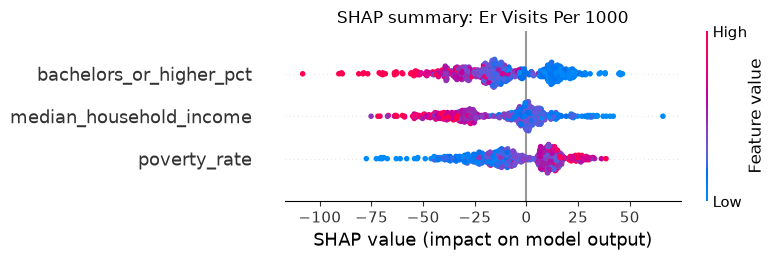


Top 10 holdout residual outliers: er_visits_per_1000
 fips        county_name  actual  predicted  residual  absolute_residual
32023             NV-Nye  258.84     691.68   -432.84             432.84
25019       MA-Nantucket  775.65     468.25    307.40             307.40
37015          NC-Bertie  922.31     622.26    300.05             300.05
37007           NC-Anson  903.02     629.84    273.18             273.18
51051       VA-Dickenson  859.43     589.10    270.33             270.33
37139      NC-Pasquotank  827.11     561.36    265.75             265.75
31085           NE-Hayes  371.31     615.63   -244.31             244.31
51730 VA-Petersburg City  885.44     641.13    244.31             244.31
55003         WI-Ashland  813.14     569.51    243.63             243.63
25025         MA-Suffolk  736.45     498.70    237.75             237.75


In [8]:
outlier_tables = {}
for target, best_model in best_tree_by_target.items():
    background = shap.maskers.Independent(X_train, max_samples=100)
    predict_from_array = lambda values: best_model.predict(
        pd.DataFrame(values, columns=feature_names)
    )
    explainer = shap.Explainer(
        predict_from_array, background, algorithm="permutation",
        feature_names=feature_names,
    )
    shap_values = explainer(X_test.to_numpy(), max_evals=63)
    mean_abs_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0), index=feature_names
    ).sort_values(ascending=False)
    print(f"\nMean absolute SHAP attribution: {target}")
    print(mean_abs_shap.round(3).to_string())
    plt.figure(figsize=(9, 5))
    shap.summary_plot(
        shap_values.values,
        X_test,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"SHAP summary: {target.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

    y_test, predictions = holdout_predictions[target]
    residuals = y_test.to_numpy() - predictions
    outliers = model_data.iloc[test_idx][["fips", "county_name"]].copy()
    outliers["actual"] = y_test.to_numpy()
    outliers["predicted"] = predictions
    outliers["residual"] = residuals
    outliers["absolute_residual"] = np.abs(residuals)
    outlier_tables[target] = outliers.nlargest(10, "absolute_residual").reset_index(drop=True)
    print(f"\nTop 10 holdout residual outliers: {target}")
    print(outlier_tables[target].round(2).to_string(index=False))

## Analysis (Report Draft)

Integrating the CMS Original Medicare Geographic Variation data with the 2024 American Community Survey (ACS) profiles made it possible to examine utilization and socioeconomic conditions on the same county geography. CMS supplied county-level inpatient, outpatient, and emergency department rates, while ACS supplied median household income, poverty, and educational attainment; neither source alone could show how these county characteristics co-vary with Medicare utilization. The join through county FIPS codes, following the CMS 2020–2024 aggregation and ACS five-year period, created a spatially comparable analytic file of 3,134 counties. The requested descriptive analysis established substantial baseline dispersion, particularly for outpatient visits (mean 5,451.30; median 5,122.82; IQR 3,133.91 per 1,000 beneficiaries), compared with inpatient stays (mean 215.48; median 215.26; IQR 53.72) and ED visits (mean 588.51; median 589.20; IQR 134.80). County maps and the linked socioeconomic measures therefore provide a way to see where utilization differences occur alongside local socioeconomic context, rather than treating either dataset as an isolated description.

Pearson and Spearman matrices, computed using `DataFrame.corr` and visualized as annotated `seaborn` heatmaps, showed the clearest socioeconomic gradients for inpatient and ED use. Poverty was positively associated with inpatient stays (Pearson *r* = 0.386; Spearman ρ = 0.372) and ED visits (0.386; 0.421), while income and bachelor's-level attainment were inversely associated with ED use (income: −0.366; −0.388; education: −0.369; −0.418). The socioeconomic indicators were themselves correlated—income and poverty *r* = −0.726, and income and educational attainment *r* = 0.717—which limits interpretation of any indicator as an independent driver. Outpatient use showed little bivariate association with income or education (Pearson *r* = −0.011 and −0.006) and a modest inverse association with poverty (−0.191). Inpatient and ED rates were positively correlated (Pearson *r* = 0.526). The somewhat stronger ED rank correlations suggest monotonic ordering that is not fully captured by linear coefficients, but neither the correlations nor the SHAP summary plots establish a discrete poverty tipping point.

For supervised prediction, the three socioeconomic indicators were predictors and each of the three utilization outcomes was modeled separately. After complete-case filtering for variables used in the models, 3,129 counties remained. `StandardScaler` pipelines were used with Ridge and Lasso; the comparison also included `RandomForestRegressor`, `XGBRegressor`, and `LGBMRegressor`. To reduce geographic leakage, `GroupShuffleSplit` held out 20% of state-FIPS groups (593 counties across 10 states), and `GroupKFold(n_splits=5)` with `cross_validate` evaluated models within the remaining 39 states. The pandas comparison table reports fold-mean and fold-standard-deviation R² and RMSE, as well as untouched holdout R² and RMSE. Thus, the CV results estimate transfer among training states, while the holdout results provide a second, state-disjoint check.

Predictive performance was limited, indicating that these three socioeconomic variables alone do not explain most county-level utilization variation. For inpatient stays, Ridge/Lasso led cross-validation (mean R² = 0.083; RMSE ≈ 38.84 per 1,000), while the best tree by CV RMSE was XGBoost (R² = 0.053; RMSE = 39.50); every model had negative holdout R², including XGBoost (−0.115). For outpatient visits, all models had negative mean CV R²; XGBoost was best among the tree ensembles (CV R² = −0.038; RMSE = 2,074.11), despite a positive holdout R² of 0.161. ED prediction was somewhat stronger: Ridge/Lasso had the best mean CV scores (R² = 0.146; RMSE ≈ 98.83), while XGBoost achieved holdout R² = 0.193 and RMSE = 91.70. This outcome-specific variation and the difference between CV and held-out results caution against treating a single split or model ranking as stable evidence of broad predictive accuracy.

No systematic hyperparameter search was conducted; the models were compared under the documented fixed settings, so the results do not identify tuned optima. The fold training scores nevertheless indicate generalization gaps for the more flexible ensembles. For example, Random Forest had mean training R² of 0.761 for inpatient stays versus mean CV R² of −0.007, and 0.758 versus −0.116 for outpatient visits; LightGBM also showed training-to-CV gaps (0.412 versus 0.012 for inpatient, 0.381 versus −0.074 for outpatient). These patterns are consistent with overfitting under the current feature set and geographic validation design. More fundamentally, the low or negative out-of-sample R²—especially for inpatient use and outpatient CV—suggests omitted determinants such as morbidity, age composition, provider capacity, access, local practice patterns, and policy may matter more than the three socioeconomic measures. The positive outpatient holdout result alongside negative CV scores also signals geographic heterogeneity rather than dependable performance across regions.

For interpretation, the lowest-CV-RMSE tree ensemble for each target was selected and evaluated with `shap.Explainer`; permutation-based explanations were summarized with `shap.summary_plot` on held-out counties. Education had the largest mean absolute SHAP attribution for inpatient stays (10.84 rate points) and ED visits (21.95), while poverty ranked first for outpatient visits (539.68 visits per 1,000), followed by income (515.61). These values rank contributions within each outcome/model and are not comparable across different outcome scales; correlated socioeconomic inputs also make individual attributions conditional on the other included features. The summary plots show feature-value gradients and spread, but do not provide evidence for a validated threshold or causal mechanism.

Finally, holdout residuals (actual minus predicted) identified counties whose rates were least consistent with socioeconomic expectations. For inpatient stays, Washington's Ferry County was markedly below prediction (115.61 actual versus 224.20 predicted; residual −108.59), while Nebraska's McPherson County was above prediction (303.51 versus 199.95; +103.56). Outpatient residuals were dominated by unexpectedly high rates in the upper Midwest, including Iowa's Sioux County (13,097.20 versus 5,551.96; +7,545.24) and Wisconsin's La Crosse County (12,716.75 versus 5,067.25; +7,649.50). For ED visits, Nevada's Nye County was well below prediction (258.84 versus 691.68; −432.84), whereas Massachusetts's Nantucket County was above prediction (775.65 versus 468.25; +307.40). These are model-relative leads for contextual investigation—not evidence of inappropriate care or individual-level behavior. The analysis is ecological, uses county averages, and does not account for spatial dependence or all relevant clinical and health-system covariates; its associations and outlier flags should therefore be interpreted as descriptive and hypothesis-generating, not causal.